In [40]:
# Using a layoff data taken from kaggle: https://www.kaggle.com/datasets/swaptr/layoffs-2022

# imported libraries

# analysing the first 5 rows

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('layoffs.csv')
df.head(5)    # i would like to drop source column and date added

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Acko,"Mumbai, Non-U.S.",60.0,4/20/2026,0.05,Finance,https://inc42.com/buzz/acko-cuts-5-workforce-i...,Unknown,143.0,India,4/20/2026
1,Meta,SF Bay Area,8000.0,4/17/2026,0.10,Consumer,https://www.reuters.com/world/meta-targets-may...,Post-IPO,26000.0,United States,4/20/2026
2,Shutterfly,"Haifa, Non-U.S.",80.0,4/16/2026,NaN,Manufacturing,https://www.calcalistech.com/ctechnews/article...,Post-IPO,50.0,United States,4/17/2026
3,Quora,SF Bay Area,NaN,4/16/2026,NaN,Consumer,https://quorablog.quora.com/Update?ch=10&oid=2...,Series D,226.0,United States,4/20/2026
4,Snap,Los Angeles,1000.0,4/15/2026,0.16,Consumer,https://www.cnbc.com/2026/04/15/snap-stock-lay...,Post-IPO,4900.0,United States,4/15/2026


In [78]:
df.info()    # 4361 rows and 11 columns

# total laid off and percentage lay offs are missing a lot of numbers probably because
# many companies donot disclose the numbers and percentage

<class 'pandas.DataFrame'>
RangeIndex: 4361 entries, 0 to 4360
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4361 non-null   str    
 1   location             4360 non-null   str    
 2   total_laid_off       2851 non-null   float64
 3   date                 4360 non-null   str    
 4   percentage_laid_off  2743 non-null   float64
 5   industry             4359 non-null   str    
 6   source               4358 non-null   str    
 7   stage                4356 non-null   str    
 8   funds_raised         3861 non-null   float64
 9   country              4359 non-null   str    
 10  date_added           4361 non-null   str    
dtypes: float64(3), str(8)
memory usage: 374.9 KB


In [79]:
df_clean = df[df['total_laid_off'].isna() & df['percentage_laid_off'].isna()]
print(f"Rows where BOTH are missing: {len(df_clean)}")

Rows where BOTH are missing: 715


In [80]:
# 715 values (~16.4%) are missing from the data (total layoff and percentage laid off)
# These values are not being included in the numerical analysis

In [81]:
df_clean = df.dropna(subset=['total_laid_off', 'percentage_laid_off'], how='all')
print(f"Rows remaining: {len(df_clean)}")

Rows remaining: 3646


In [82]:
df_clean = df_clean.drop(columns=['source', 'date_added'])

# dropping source column and fate added as contains metadata irrelevant to the numerical analysis for now.

In [83]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 3646 entries, 0 to 4360
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              3646 non-null   str    
 1   location             3645 non-null   str    
 2   total_laid_off       2851 non-null   float64
 3   date                 3645 non-null   str    
 4   percentage_laid_off  2743 non-null   float64
 5   industry             3644 non-null   str    
 6   stage                3642 non-null   str    
 7   funds_raised         3244 non-null   float64
 8   country              3644 non-null   str    
dtypes: float64(3), str(6)
memory usage: 284.8 KB


In [84]:
# data types need fixing : date and total laid off column

df_clean['date'] = pd.to_datetime(df_clean['date'])  # conversion of date (str) to datetime

df_clean['total_laid_off'] = df_clean['total_laid_off'].astype('Int64')

# conversion of float values to rounded integers

df_clean = df_clean.dropna(subset=['company', 'location', 'industry', 'country', 'stage'])

# removing Nan values from str columns

In [85]:
# Now converting all the Nan values in Funds raised column as 0

df_clean['funds_raised'] = df_clean['funds_raised'].fillna(0)

# Converting all the nan in str columns as NA

df_clean['percentage_laid_off'] = df_clean['percentage_laid_off'].fillna("NA")

df_clean.info()

<class 'pandas.DataFrame'>
Index: 3637 entries, 0 to 4360
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              3637 non-null   str           
 1   location             3637 non-null   str           
 2   total_laid_off       2848 non-null   Int64         
 3   date                 3636 non-null   datetime64[us]
 4   percentage_laid_off  3637 non-null   object        
 5   industry             3637 non-null   str           
 6   stage                3637 non-null   str           
 7   funds_raised         3637 non-null   float64       
 8   country              3637 non-null   str           
dtypes: Int64(1), datetime64[us](1), float64(1), object(1), str(5)
memory usage: 287.7+ KB


In [86]:
df_clean = df_clean.reset_index(drop=True)
df_clean.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,stage,funds_raised,country
0,Acko,"Mumbai, Non-U.S.",60,2026-04-20,0.05,Finance,Unknown,143.0,India
1,Meta,SF Bay Area,8000,2026-04-17,0.1,Consumer,Post-IPO,26000.0,United States
2,Shutterfly,"Haifa, Non-U.S.",80,2026-04-16,NA,Manufacturing,Post-IPO,50.0,United States
3,Snap,Los Angeles,1000,2026-04-15,0.16,Consumer,Post-IPO,4900.0,United States
4,UKG,Boston,950,2026-04-15,NA,HR,Unknown,0.0,United States


Column units reference:
- total_laid_off → actual number of individual employees laid off
- percentage_laid_off → proportion of total workforce (0.05 = 5%)
- funds_raised → in millions of dollars (USD)

In [87]:
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_year'] = df_clean['date'].dt.to_period('M')

#Extracting the year, month, date for time based analysis

EDA:

/var/folders/s0/cbmnbkcn29nfgq26np32r31w0000gn/T/ipykernel_70147/1191017638.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x='year', y='total_laid_off', palette='Reds_r', ax=ax)


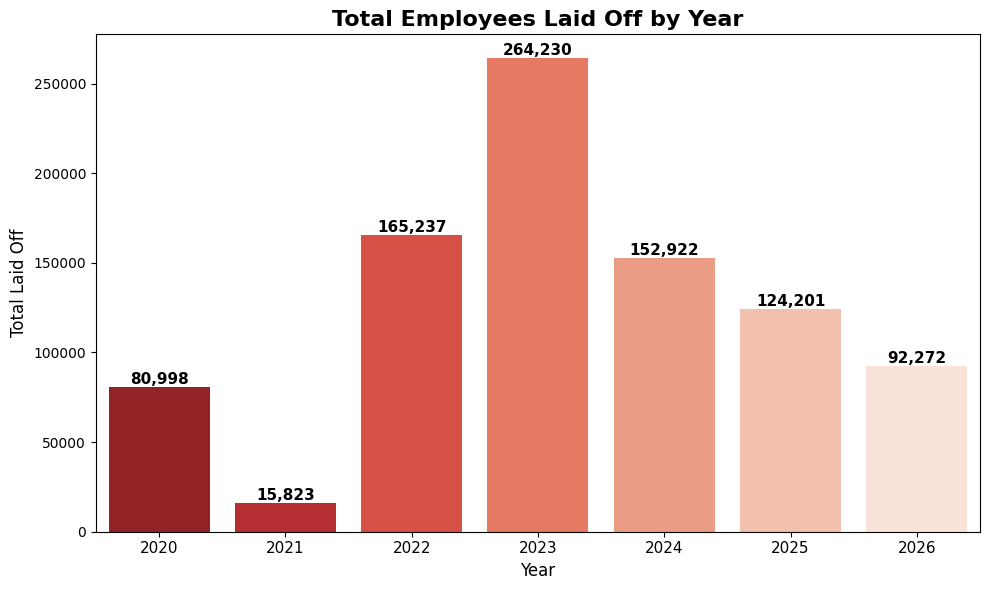

In [ ]:
# Q1 which year hit the hardest?

fig, ax = plt.subplots(figsize=(10, 6))

yearly = df_clean.groupby('year')['total_laid_off'].sum().reset_index()
yearly['total_laid_off'] = yearly['total_laid_off'].astype(float)

sns.barplot(data=yearly, x='year', y='total_laid_off', palette='Reds_r', ax=ax)

ax.set_title('Total Employees Laid Off by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Laid Off', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([str(int(x)) for x in yearly['year']], fontsize=11)

plt.tight_layout()
plt.show()

**Finding 1: 2023 Was the True Peak**
- 2023 recorded 264,230 layoffs — 60% more than 2022 (165,237)
- 2022 felt worse due to sudden shock; 2023 was worse in actual scale
- 2021 shows just 15,823 — the height of the post-pandemic hiring boom
- That overhiring directly caused the correction seen in 2022–2023
- 2024–2026 show decline but layoffs remain sustained — now a normalized business tool

/var/folders/s0/cbmnbkcn29nfgq26np32r31w0000gn/T/ipykernel_70147/3098567287.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry, y='industry', x='total_laid_off', palette='Oranges_r', ax=ax)


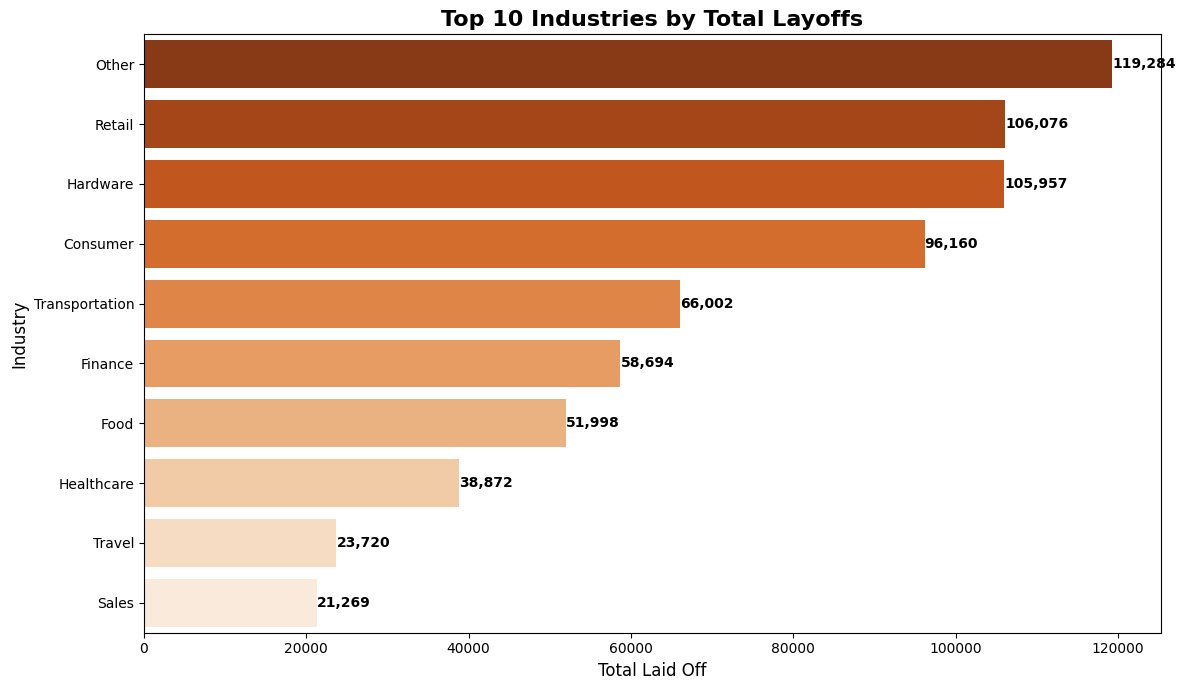

In [90]:
# Q2 — Which industries were hit hardest?

fig, ax = plt.subplots(figsize=(12, 7))

industry = df_clean.groupby('industry')['total_laid_off'].sum().astype(float).reset_index()
industry = industry.sort_values('total_laid_off', ascending=False).head(10)

sns.barplot(data=industry, y='industry', x='total_laid_off', palette='Oranges_r', ax=ax)

ax.set_title('Top 10 Industries by Total Layoffs', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Laid Off', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding 2: Consumer-Facing Industries Dominated Layoffs**
- Retail (106K) and Hardware (106K) hit hardest — both B2C, spending-sensitive
- Finance and Transportation over-hired during fintech/delivery boom, now correcting
- Enterprise/B2B software notably absent — far more resilient than consumer tech

/var/folders/s0/cbmnbkcn29nfgq26np32r31w0000gn/T/ipykernel_70147/2995902496.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=companies, y='company', x='total_laid_off', palette='Blues_r', ax=ax)


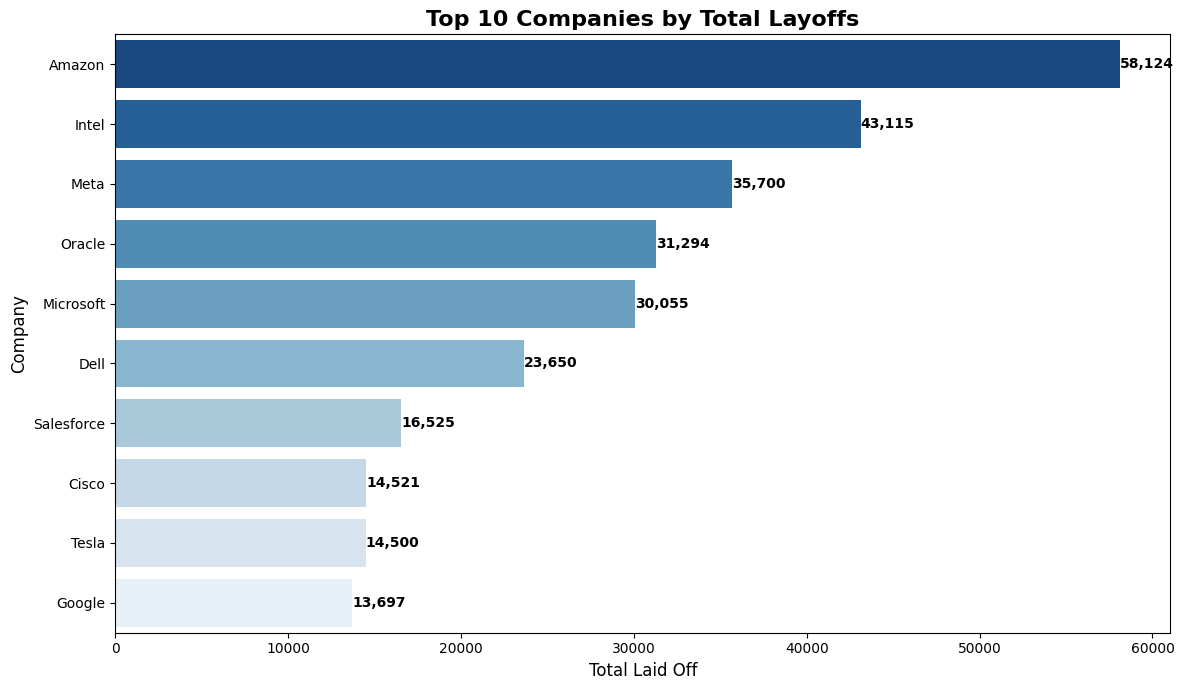

In [91]:
#Q3 — Which companies laid off the most?

fig, ax = plt.subplots(figsize=(12, 7))

companies = df_clean.groupby('company')['total_laid_off'].sum().astype(float).reset_index()
companies = companies.sort_values('total_laid_off', ascending=False).head(10)

sns.barplot(data=companies, y='company', x='total_laid_off', palette='Blues_r', ax=ax)

ax.set_title('Top 10 Companies by Total Layoffs', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Laid Off', fontsize=12)
ax.set_ylabel('Company', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding 3: Big Tech Led Layoffs in Absolute Numbers**
- Amazon tops at 58,124 — driven by post-pandemic logistics over-expansion
- Intel (43,115) reflects a structural crisis, not cyclical — losing ground to AI chips
- All top 10 are established giants, not startups — size amplifies absolute cut numbers

/var/folders/s0/cbmnbkcn29nfgq26np32r31w0000gn/T/ipykernel_70147/2672602363.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=countries, y='country', x='total_laid_off', palette='Greens_r', ax=ax)


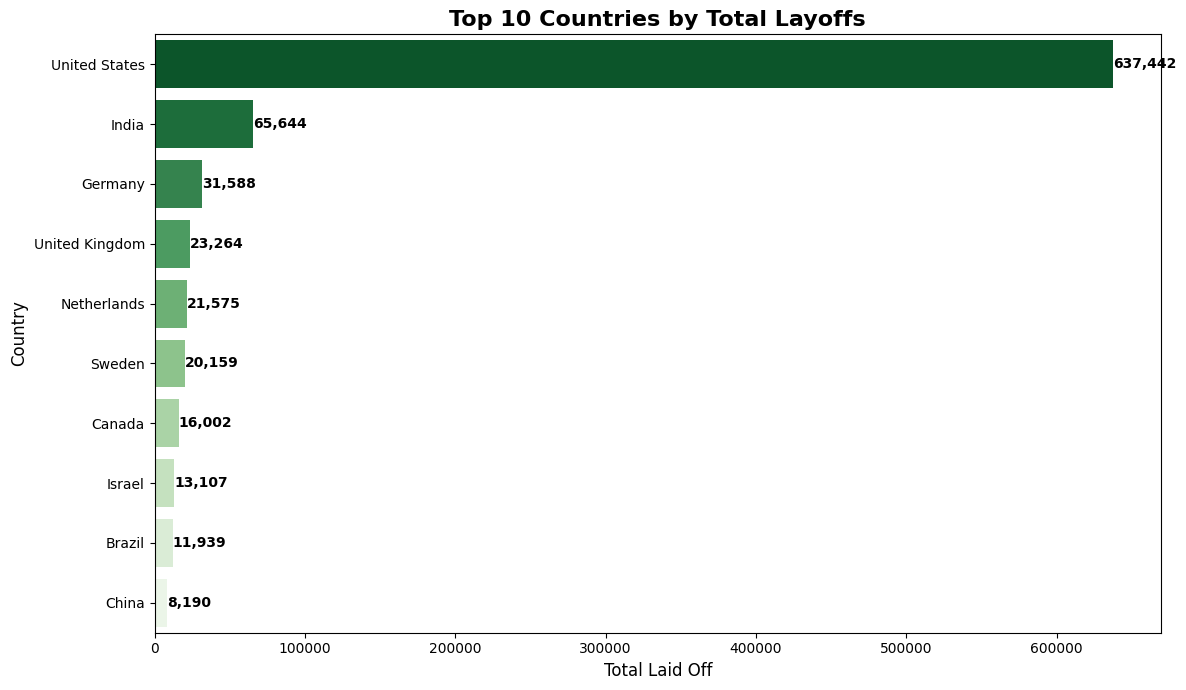

In [107]:
#Q4 — Which countries were most affected?

fig, ax = plt.subplots(figsize=(12, 7))

countries = df_clean.groupby('country')['total_laid_off'].sum().astype(float).reset_index()
countries = countries.sort_values('total_laid_off', ascending=False).head(10)

sns.barplot(data=countries, y='country', x='total_laid_off', palette='Greens_r', ax=ax)

ax.set_title('Top 10 Countries by Total Layoffs', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Laid Off', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding 4: This Is Overwhelmingly a US Problem — But India Is #2**
- USA accounts for 637,442 layoffs — dwarfing every other country combined
- India ranks #2 at 65,644 — significant given most layoffs hit US-headquartered 
  companies' Indian offices, not Indian-origin firms
- No Asian tech giant (China, Japan, Korea) appears prominently — layoff culture 
  is largely a Western/US-listed company phenomenon

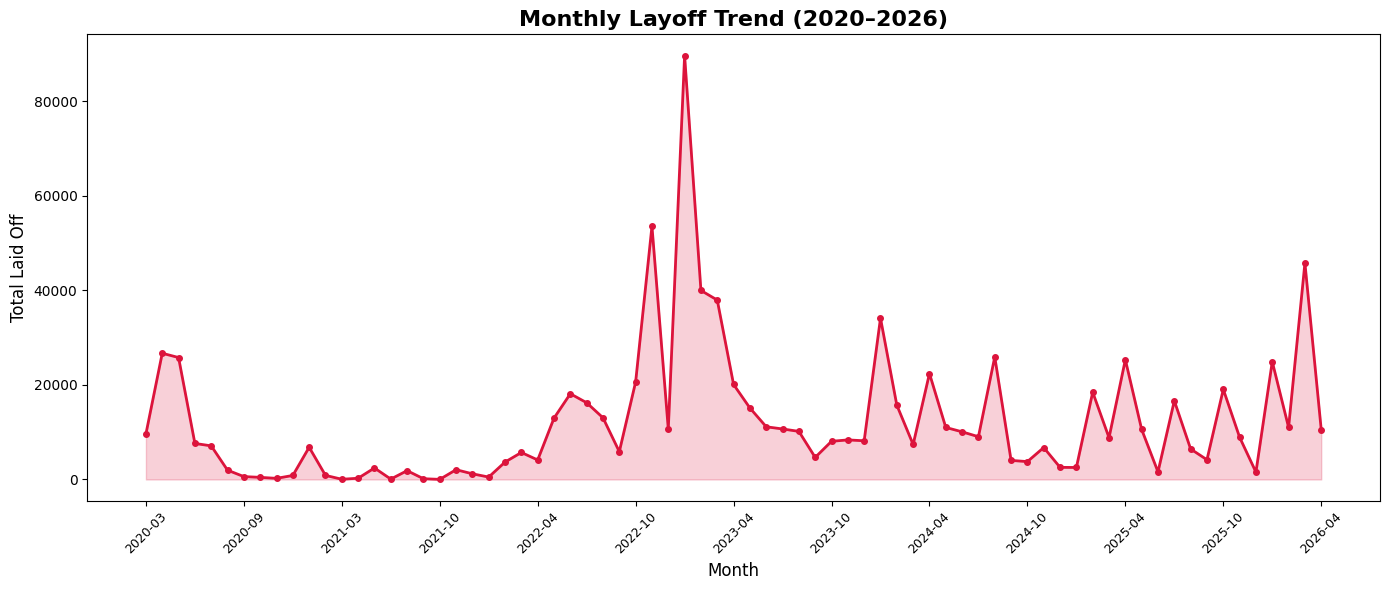

In [108]:
#Q5 — Layoff trend over time (monthly)

fig, ax = plt.subplots(figsize=(14, 6))

monthly = df_clean.groupby('month_year')['total_laid_off'].sum().astype(float).reset_index()
monthly['month_year_str'] = monthly['month_year'].astype(str)

ax.plot(monthly['month_year_str'], monthly['total_laid_off'], 
        color='crimson', linewidth=2, marker='o', markersize=4)

ax.fill_between(monthly['month_year_str'], monthly['total_laid_off'], 
                alpha=0.2, color='crimson')

ax.set_title('Monthly Layoff Trend (2020–2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Laid Off', fontsize=12)

# Show only every 6th label to avoid clutter
tick_positions = range(0, len(monthly), 6)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly['month_year_str'].iloc[i] for i in tick_positions], 
                    rotation=45, fontsize=9)

plt.tight_layout()
plt.show()

**Finding 5: Layoffs Follow a Predictable Seasonal Spike Pattern**
- The Jan 2023 spike (~90K) is the single largest month — post-bonus, new fiscal year cuts
- Every January shows a visible spike — layoffs are timed around compensation cycles
- 2021 is nearly flat — confirming it as the hiring boom period with minimal cuts
- Post-2023 the baseline stays elevated — layoffs never returned to pre-2022 calm

/var/folders/s0/cbmnbkcn29nfgq26np32r31w0000gn/T/ipykernel_70147/996555298.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stage, y='stage', x='total_laid_off', palette='Purples_r', ax=ax)


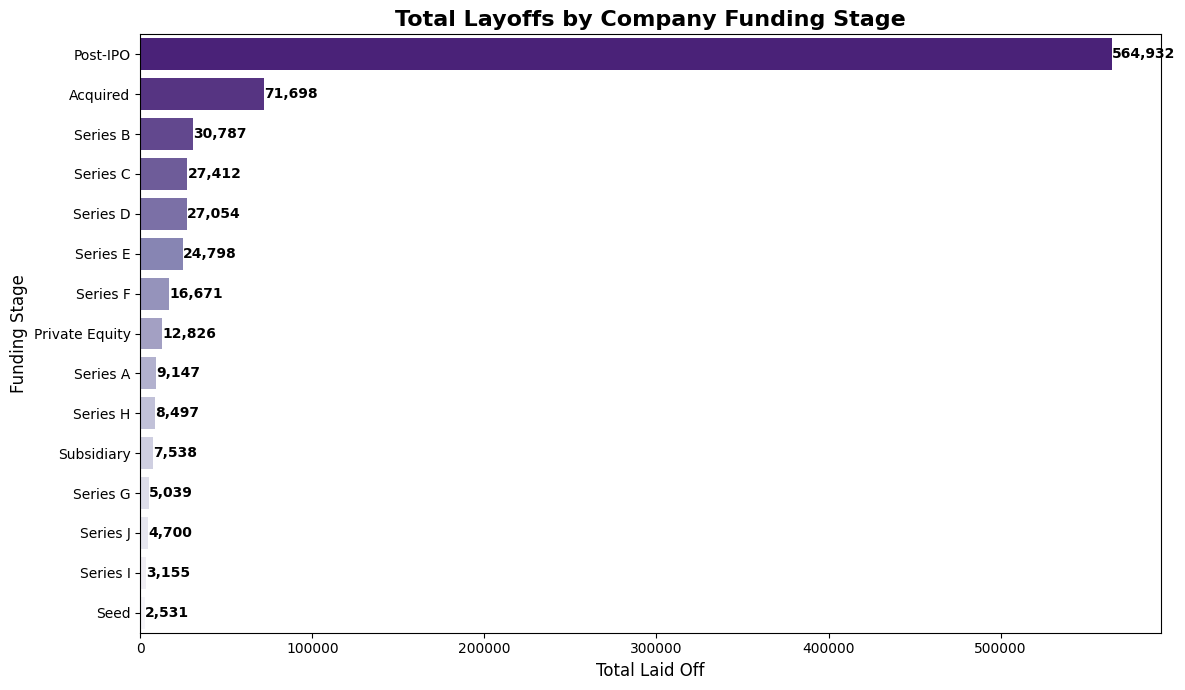

In [109]:
#Q6 — Funding stage vs layoffs.

fig, ax = plt.subplots(figsize=(12, 7))

stage = df_clean.groupby('stage')['total_laid_off'].sum().astype(float).reset_index()
stage = stage.sort_values('total_laid_off', ascending=False)

# Remove unknown
stage = stage[stage['stage'] != 'Unknown']

sns.barplot(data=stage, y='stage', x='total_laid_off', palette='Purples_r', ax=ax)

ax.set_title('Total Layoffs by Company Funding Stage', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Laid Off', fontsize=12)
ax.set_ylabel('Funding Stage', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding 6: Public Companies Cut the Most — But That's a Size Effect**
- Post-IPO companies account for 564,932 layoffs — 70%+ of all recorded cuts
- This reflects size, not dysfunction — public companies simply employ more people
- Early-stage (Seed, Series A) barely register — small teams have little room to cut
- Acquired companies (71,698) show significant cuts — M&A restructuring is a major 
  layoff trigger often ignored in mainstream coverage

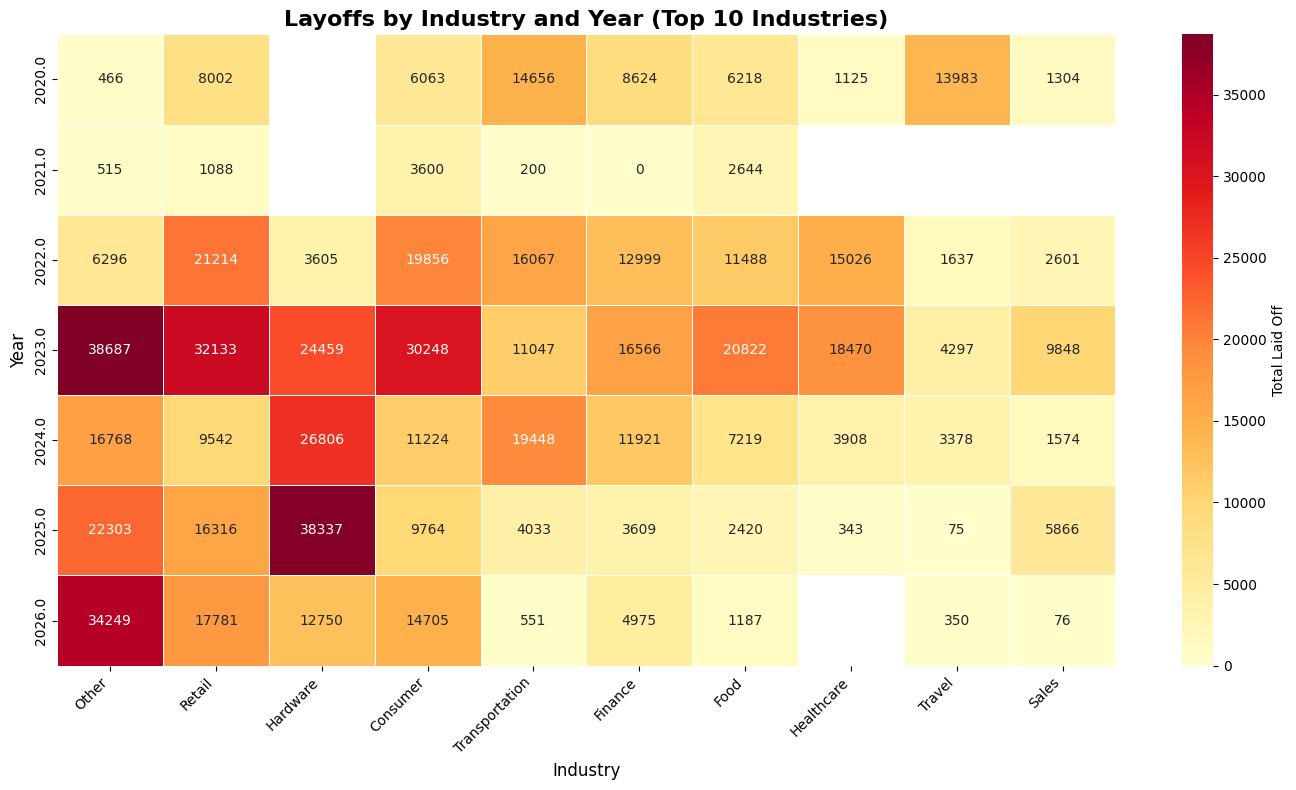

In [110]:
#a heatmap of layoffs by industry and year

fig, ax = plt.subplots(figsize=(14, 8))

heatmap_data = df_clean.groupby(['year', 'industry'])['total_laid_off'].sum().astype(float).unstack()
heatmap_data = heatmap_data[heatmap_data.sum().sort_values(ascending=False).head(10).index]

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Total Laid Off'})

ax.set_title('Layoffs by Industry and Year (Top 10 Industries)', fontsize=16, fontweight='bold')
ax.set_xlabel('Industry', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

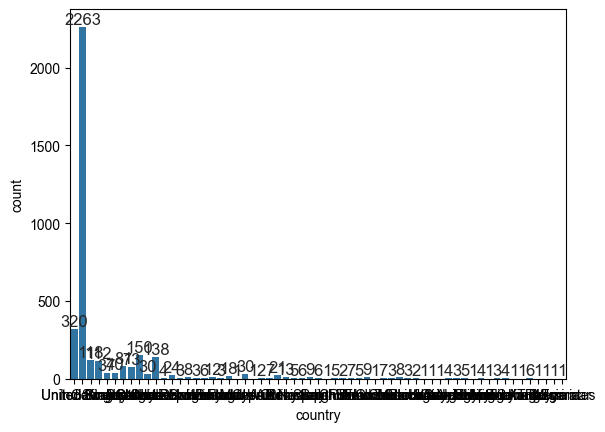

In [112]:
ax = sns.countplot (x = 'country', data = df_clean)

sns.set(rc={'figure.figsize':(15,5)})

for bars in ax.containers:
    ax.bar_label(bars)